In [1]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn

In [2]:
import kagglehub
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")

dataset_path = os.path.join(path, "Dataset_BUSI_with_GT")

print("Dataset downloaded at:", dataset_path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded at: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [4]:
import shutil
import os

destination = "/kaggle/working/Dataset_BUSI_with_GT"

if not os.path.exists(destination):
    shutil.copytree(dataset_path, destination)

dataset_path = destination

In [5]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if "_mask" in file:
            os.remove(os.path.join(root, file))

In [6]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 625 images belonging to 3 classes.
Found 155 images belonging to 3 classes.


In [7]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [8]:
x = base_model.output

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.5)(x)

output = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6112 - loss: 1.2360 - val_accuracy: 0.6710 - val_loss: 1.0663
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 742ms/step - accuracy: 0.6752 - loss: 0.7878 - val_accuracy: 0.6387 - val_loss: 0.9175
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 727ms/step - accuracy: 0.7296 - loss: 0.6380 - val_accuracy: 0.7097 - val_loss: 0.7699
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 807ms/step - accuracy: 0.7680 - loss: 0.6112 - val_accuracy: 0.6710 - val_loss: 0.9424
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 738ms/step - accuracy: 0.7536 - loss: 0.5962 - val_accuracy: 0.7097 - val_loss: 0.7120
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 733ms/step - accuracy: 0.7808 - loss: 0.5565 - val_accuracy: 0.7097 - val_loss: 0.8187
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 724ms/step - accuracy: 0.7712 - loss: 0.5394 - val_accuracy: 0.6968 - val_loss: 0.6822
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 725ms/step - accuracy: 0.7856 - loss: 0.5326 - val_accurac

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6912 - loss: 0.7831 - val_accuracy: 0.7419 - val_loss: 0.7525
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 739ms/step - accuracy: 0.7936 - loss: 0.4718 - val_accuracy: 0.6968 - val_loss: 0.7204
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 736ms/step - accuracy: 0.8192 - loss: 0.4527 - val_accuracy: 0.7355 - val_loss: 0.7539
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 730ms/step - accuracy: 0.8448 - loss: 0.4155 - val_accuracy: 0.7548 - val_loss: 0.7512
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 732ms/step - accuracy: 0.8528 - loss: 0.3817 - val_accuracy: 0.7613 - val_loss: 0.7723
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 783ms/step - accuracy: 0.8512 - loss: 0.3488 - val_accuracy: 0.7484 - val_loss: 0.7473
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 737ms/step - accuracy: 0.8800 - loss: 0.3024 - val_accuracy: 0.7548 - val_loss: 0.7428
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 736ms/step - accuracy: 0.8848 - loss: 0.2989 - val_accurac

In [14]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 748ms/step - accuracy: 0.7613 - loss: 0.7734
Validation Accuracy: 0.7612903118133545


In [15]:
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


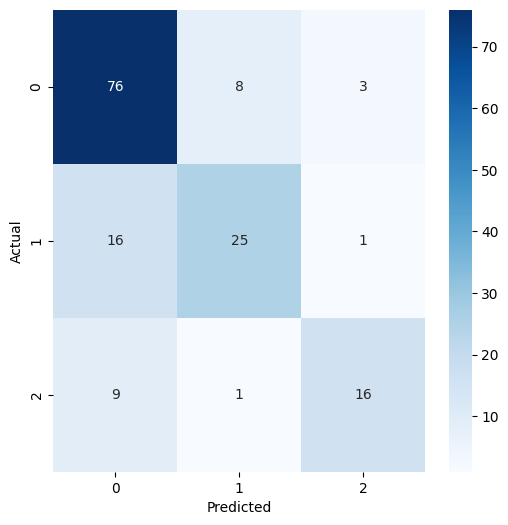

In [16]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=list(val_data.class_indices.keys())
))

              precision    recall  f1-score   support

      benign       0.75      0.87      0.81        87
   malignant       0.74      0.60      0.66        42
      normal       0.80      0.62      0.70        26

    accuracy                           0.75       155
   macro avg       0.76      0.69      0.72       155
weighted avg       0.76      0.75      0.75       155



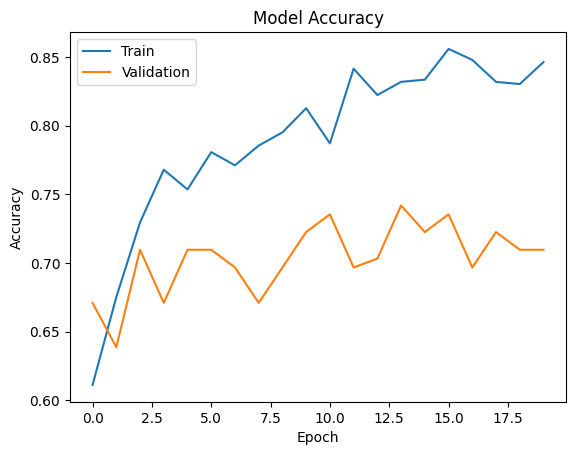

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()